# Portfolio Project: Online Retail Exploratory Data Analysis with Python

## Overview

In this project, you will step into the shoes of an entry-level data analyst at an online retail company, helping interpret real-world data to help make a key business decision.

## Case Study
In this project, you will be working with transactional data from an online retail store. The dataset contains information about customer purchases, including product details, quantities, prices, and timestamps. Your task is to explore and analyze this dataset to gain insights into the store's sales trends, customer behavior, and popular products. 

By conducting exploratory data analysis, you will identify patterns, outliers, and correlations in the data, allowing you to make data-driven decisions and recommendations to optimize the store's operations and improve customer satisfaction. Through visualizations and statistical analysis, you will uncover key trends, such as the busiest sales months, best-selling products, and the store's most valuable customers. Ultimately, this project aims to provide actionable insights that can drive strategic business decisions and enhance the store's overall performance in the competitive online retail market.

## Prerequisites

Before starting this project, you should have some basic knowledge of Python programming and Pandas. In addition, you may want to use the following packages in your Python environment:

- pandas
- numpy
- seaborn
- matplotlib

These packages should already be installed in Coursera's Jupyter Notebook environment, however if you'd like to install additional packages that are not included in this environment or are working off platform you can install additional packages using `!pip install packagename` within a notebook cell such as:

- `!pip install pandas`
- `!pip install matplotlib`

## Project Objectives
1. Describe data to answer key questions to uncover insights
2. Gain valuable insights that will help improve online retail performance
3. Provide analytic insights and data-driven recommendations

## Dataset

The dataset you will be working with is the "Online Retail" dataset. It contains transactional data of an online retail store from 2010 to 2011. The dataset is available as a .xlsx file named `Online Retail.xlsx`. This data file is already included in the Coursera Jupyter Notebook environment, however if you are working off-platform it can also be downloaded [here](https://archive.ics.uci.edu/ml/machine-learning-databases/00352/Online%20Retail.xlsx).

The dataset contains the following columns:

- InvoiceNo: Invoice number of the transaction
- StockCode: Unique code of the product
- Description: Description of the product
- Quantity: Quantity of the product in the transaction
- InvoiceDate: Date and time of the transaction
- UnitPrice: Unit price of the product
- CustomerID: Unique identifier of the customer
- Country: Country where the transaction occurred

## Tasks

You may explore this dataset in any way you would like - however if you'd like some help getting started, here are a few ideas:

1. Load the dataset into a Pandas DataFrame and display the first few rows to get an overview of the data.
2. Perform data cleaning by handling missing values, if any, and removing any redundant or unnecessary columns.
3. Explore the basic statistics of the dataset, including measures of central tendency and dispersion.
4. Perform data visualization to gain insights into the dataset. Generate appropriate plots, such as histograms, scatter plots, or bar plots, to visualize different aspects of the data.
5. Analyze the sales trends over time. Identify the busiest months and days of the week in terms of sales.
6. Explore the top-selling products and countries based on the quantity sold.
7. Identify any outliers or anomalies in the dataset and discuss their potential impact on the analysis.
8. Draw conclusions and summarize your findings from the exploratory data analysis.

## Task 1: Load the Data

In [13]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

In [14]:
df = pd.read_excel("Online Retail.xlsx")

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [15]:

print("Rows and Columns:", df.shape)


df.info()


df.isnull().sum()

Rows and Columns: (541909, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [16]:
df[df.isnull().any(axis=1)].head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
622,536414,22139,NaN,56,2010-12-01 11:52:00,0.00,NaN,United Kingdom
1443,536544,21773,DECORATIVE ROSE BATHROOM BOTTLE,1,2010-12-01 14:32:00,2.51,NaN,United Kingdom
1444,536544,21774,DECORATIVE CATS BATHROOM BOTTLE,2,2010-12-01 14:32:00,2.51,NaN,United Kingdom
1445,536544,21786,POLKADOT RAIN HAT,4,2010-12-01 14:32:00,0.85,NaN,United Kingdom
1446,536544,21787,RAIN PONCHO RETROSPOT,2,2010-12-01 14:32:00,1.66,NaN,United Kingdom


In [17]:
df = df.dropna()

In [19]:
print("Duplicate rows:", df.duplicated().sum())
df = df.drop_duplicates()

Duplicate rows: 0


In [20]:
df.describe()

,Quantity,UnitPrice,CustomerID
count,401604.000000,401604.000000,401604.000000
mean,12.183273,3.474064,15281.160818
std,250.283037,69.764035,1714.006089
min,-80995.000000,0.000000,12346.000000
25%,2.000000,1.250000,13939.000000
50%,5.000000,1.950000,15145.000000
75%,12.000000,3.750000,16784.000000
max,80995.000000,38970.000000,18287.000000


In [21]:
df['Sales'] = df['Quantity'] * df['UnitPrice']

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Sales
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


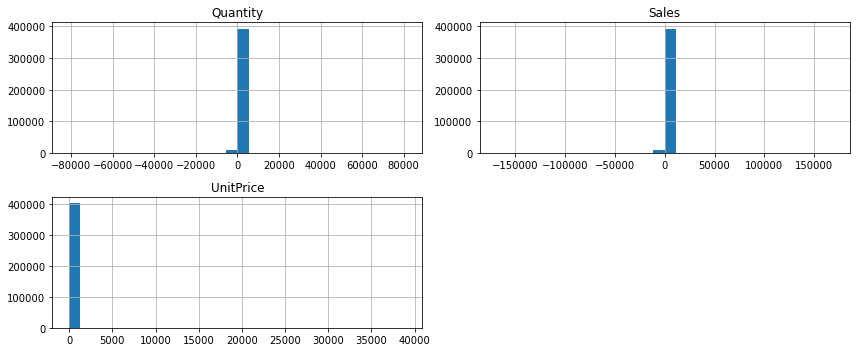

In [22]:
df[['Quantity','UnitPrice','Sales']].hist(
    figsize=(12,5),
    bins=30
)

plt.tight_layout()
plt.show()

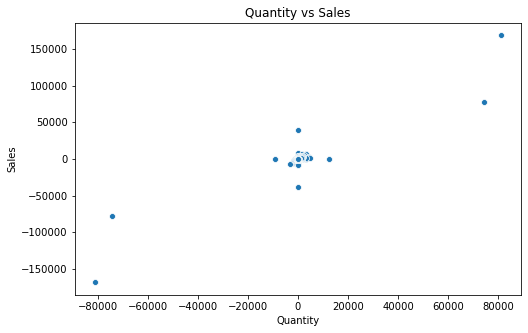

In [23]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x='Quantity',
    y='Sales',
    data=df
)

plt.title("Quantity vs Sales")
plt.show()

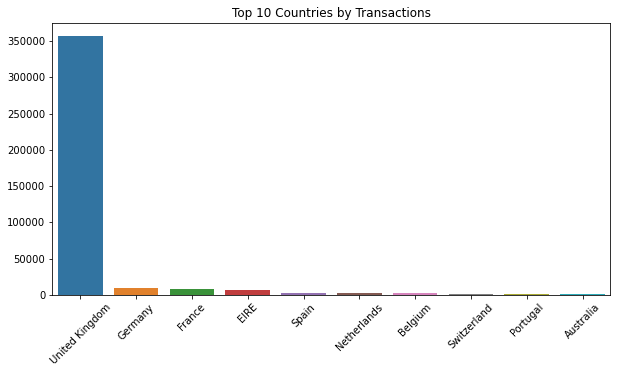

In [24]:
top_countries = df['Country'].value_counts().head(10)

plt.figure(figsize=(10,5))

sns.barplot(
    x=top_countries.index,
    y=top_countries.values
)

plt.xticks(rotation=45)
plt.title("Top 10 Countries by Transactions")
plt.show()

In [25]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [26]:
df['Month'] = df['InvoiceDate'].dt.month_name()

df['DayOfWeek'] = df['InvoiceDate'].dt.day_name()

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Sales,Month,DayOfWeek
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,December,Wednesday
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,December,Wednesday
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,December,Wednesday
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,December,Wednesday
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,December,Wednesday


In [27]:
monthly_sales = df.groupby('Month')['Sales'].sum()

monthly_sales

Month
April         425222.671
August        615078.090
December      893912.290
February      435534.070
January       473731.900
July          573112.321
June          606862.520
March         578576.210
May           647011.670
November     1126815.070
October       973306.380
September     929356.232
Name: Sales, dtype: float64

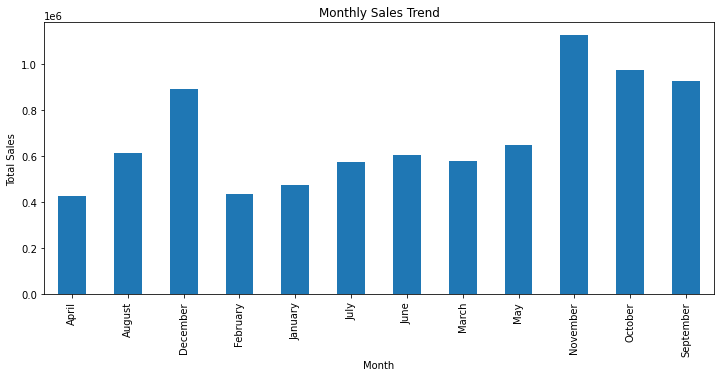

In [28]:
plt.figure(figsize=(12,5))

monthly_sales.plot(
    kind='bar'
)

plt.title("Monthly Sales Trend")
plt.ylabel("Total Sales")
plt.show()

In [29]:
monthly_sales = df.groupby('Month')['Sales'].sum()

print("Busiest Month:")
print(monthly_sales.sort_values(ascending=False).head(1))

Busiest Month:
Month
November    1126815.07
Name: Sales, dtype: float64


In [30]:
day_sales = df.groupby('DayOfWeek')['Sales'].sum()

day_sales

DayOfWeek
Friday       1238556.741
Monday       1271078.601
Sunday        777412.351
Thursday     1902316.050
Tuesday      1562715.681
Wednesday    1526440.000
Name: Sales, dtype: float64

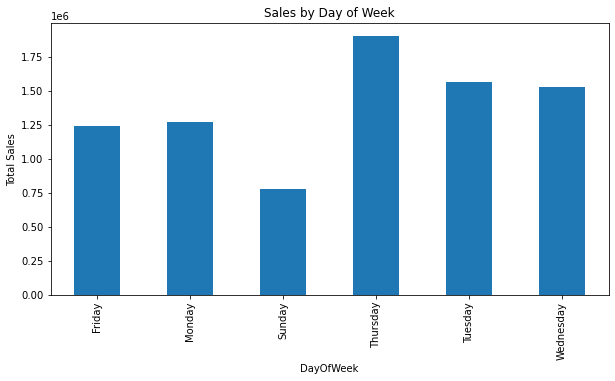

In [31]:
plt.figure(figsize=(10,5))

day_sales.plot(
    kind='bar'
)

plt.title("Sales by Day of Week")
plt.ylabel("Total Sales")
plt.show()

In [32]:
print("Busiest Day:")
print(day_sales.sort_values(ascending=False).head(1))

Busiest Day:
DayOfWeek
Thursday    1902316.05
Name: Sales, dtype: float64


In [33]:
top_products = df.groupby('Description')['Quantity'].sum()

top_products = top_products.sort_values(
    ascending=False
).head(10)

print(top_products)

Description
WORLD WAR 2 GLIDERS ASSTD DESIGNS     53119
JUMBO BAG RED RETROSPOT               44963
ASSORTED COLOUR BIRD ORNAMENT         35215
WHITE HANGING HEART T-LIGHT HOLDER    34128
PACK OF 72 RETROSPOT CAKE CASES       33386
POPCORN HOLDER                        30492
RABBIT NIGHT LIGHT                    27045
MINI PAINT SET VINTAGE                25880
PACK OF 12 LONDON TISSUES             25305
PACK OF 60 PINK PAISLEY CAKE CASES    24129
Name: Quantity, dtype: int64


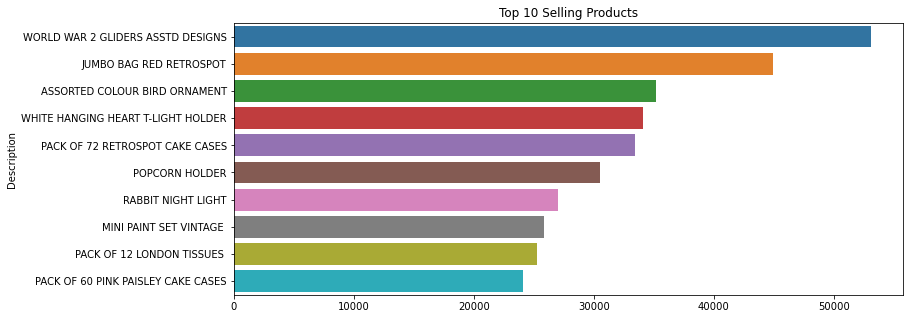

In [34]:
plt.figure(figsize=(12,5))

sns.barplot(
    x=top_products.values,
    y=top_products.index
)

plt.title("Top 10 Selling Products")
plt.show()

In [35]:
country_sales = df.groupby('Country')['Quantity'].sum()

country_sales = country_sales.sort_values(
    ascending=False
).head(10)

print(country_sales)

Country
United Kingdom    3994870
Netherlands        200128
EIRE               136187
Germany            117341
France             109806
Australia           83643
Sweden              35632
Switzerland         29778
Spain               26817
Japan               25218
Name: Quantity, dtype: int64


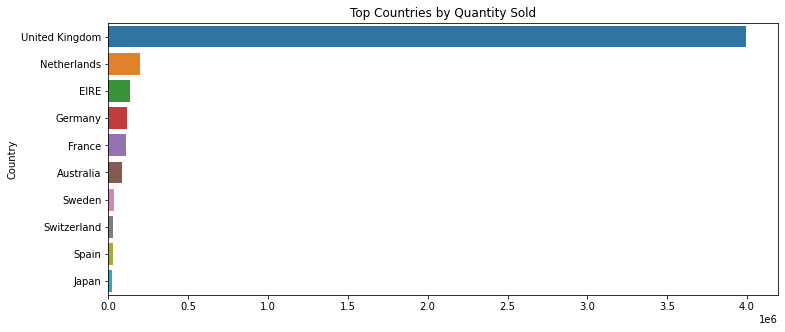

In [36]:
plt.figure(figsize=(12,5))

sns.barplot(
    x=country_sales.values,
    y=country_sales.index
)

plt.title("Top Countries by Quantity Sold")
plt.show()

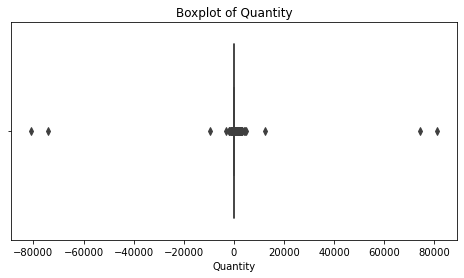

In [37]:
plt.figure(figsize=(8,4))

sns.boxplot(
    x=df['Quantity']
)

plt.title("Boxplot of Quantity")
plt.show()

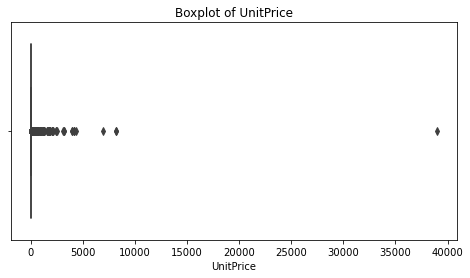

In [38]:
plt.figure(figsize=(8,4))

sns.boxplot(
    x=df['UnitPrice']
)

plt.title("Boxplot of UnitPrice")
plt.show()

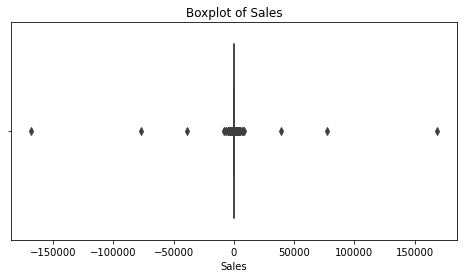

In [39]:
plt.figure(figsize=(8,4))

sns.boxplot(
    x=df['Sales']
)

plt.title("Boxplot of Sales")
plt.show()

In [40]:
Q1 = df['Sales'].quantile(0.25)
Q3 = df['Sales'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5*IQR
upper = Q3 + 1.5*IQR

outliers = df[
    (df['Sales'] < lower) |
    (df['Sales'] > upper)
]

print("Number of outliers:", len(outliers))

Number of outliers: 32938


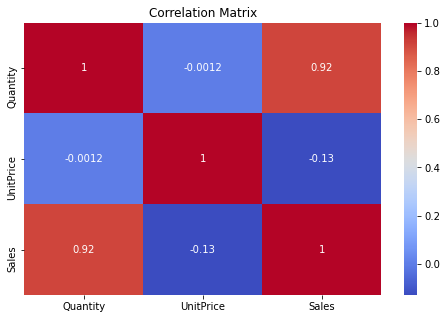

In [41]:
plt.figure(figsize=(8,5))

sns.heatmap(
    df[['Quantity','UnitPrice','Sales']].corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Matrix")
plt.show()